In [70]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [71]:
import os
import json
import requests
import pandas as pd
import numpy as np

print("Libraries loaded!")

Libraries loaded!


In [72]:
# Chiang Mai coordinates
LATITUDE = 18.80
LONGITUDE = 99.00

# Date range
START_DATE = "2023-01-01"
END_DATE = "2026-08-31"

# Create folders
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/results", exist_ok=True)

print("Folders created!")

Folders created!


In [73]:
air_url = "https://air-quality-api.open-meteo.com/v1/air-quality"

air_params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "hourly": "pm2_5,pm10,carbon_monoxide,dust",
    "start_date": START_DATE,
    "end_date": END_DATE,
    "timezone": "Asia/Bangkok"
}

air_response = requests.get(air_url, params=air_params)
air_response.raise_for_status()

air_data = air_response.json()

print("Air quality data downloaded!")
print("Latitude:", air_data["latitude"])
print("Longitude:", air_data["longitude"])
print("Timezone:", air_data["timezone"])

Air quality data downloaded!
Latitude: 18.800003
Longitude: 99.0
Timezone: Asia/Bangkok


In [74]:
with open("data/raw/open_meteo_air_quality.json", "w") as f:
    json.dump(air_data, f, indent=4)

print("Raw air quality data saved!")

Raw air quality data saved!


In [75]:
weather_url = "https://archive-api.open-meteo.com/v1/archive"

weather_params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "hourly": (
        "temperature_2m,"
        "relative_humidity_2m,"
        "wind_speed_10m,"
        "wind_direction_10m,"
        "precipitation,"
        "surface_pressure"
    ),
    "start_date": START_DATE,
    "end_date": END_DATE,
    "timezone": "Asia/Bangkok"
}

weather_response = requests.get(weather_url, params=weather_params)
weather_response.raise_for_status()

weather_data = weather_response.json()

print("Weather data downloaded!")
print("Latitude:", weather_data["latitude"])
print("Longitude:", weather_data["longitude"])
print("Timezone:", weather_data["timezone"])

Weather data downloaded!
Latitude: 18.80492
Longitude: 99.02655
Timezone: Asia/Bangkok


In [76]:
with open("data/raw/open_meteo_weather_archive.json", "w") as f:
    json.dump(weather_data, f, indent=4)

print("Raw weather data saved!")

Raw weather data saved!


In [77]:
air_df = pd.DataFrame(air_data["hourly"])

air_df["time"] = pd.to_datetime(air_df["time"])

print("Air Quality Shape:", air_df.shape)

air_df.head()

Air Quality Shape: (32136, 5)


,time,pm2_5,pm10,carbon_monoxide,dust
0,2023-01-01 00:00:00,30.0,43.1,1917.0,0.0
1,2023-01-01 01:00:00,30.6,43.9,2051.0,0.0
2,2023-01-01 02:00:00,31.7,45.4,2101.0,0.0
3,2023-01-01 03:00:00,32.8,47.1,2120.0,0.0
4,2023-01-01 04:00:00,33.2,47.7,2173.0,0.0


In [78]:
weather_df = pd.DataFrame(weather_data["hourly"])

weather_df["time"] = pd.to_datetime(weather_df["time"])

print("Weather Shape:", weather_df.shape)

weather_df.head()

Weather Shape: (32136, 7)


,time,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,precipitation,surface_pressure
0,2023-01-01 00:00:00,20.3,73,1.9,68,0.0,981.9
1,2023-01-01 01:00:00,19.0,80,3.3,41,0.0,981.5
2,2023-01-01 02:00:00,17.3,89,5.5,328,0.0,981.1
3,2023-01-01 03:00:00,18.7,80,4.2,340,0.0,980.9
4,2023-01-01 04:00:00,18.8,80,0.7,90,0.0,980.8


In [79]:
print("Air Quality")
print("Start:", air_df["time"].min())
print("End:", air_df["time"].max())
print("Rows:", len(air_df))

print()

print("Weather")
print("Start:", weather_df["time"].min())
print("End:", weather_df["time"].max())
print("Rows:", len(weather_df))

Air Quality
Start: 2023-01-01 00:00:00
End: 2026-08-31 23:00:00
Rows: 32136

Weather
Start: 2023-01-01 00:00:00
End: 2026-08-31 23:00:00
Rows: 32136


In [80]:
print(
    "Time axes identical:",
    air_df["time"].equals(weather_df["time"])
)

Time axes identical: True


In [81]:
hourly_df = pd.merge(
    air_df,
    weather_df,
    on="time",
    how="inner"
)

print("Air rows:", len(air_df))
print("Weather rows:", len(weather_df))
print("After join:", len(hourly_df))

hourly_df.head()

Air rows: 32136
Weather rows: 32136
After join: 32136


,time,pm2_5,pm10,carbon_monoxide,dust,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,precipitation,surface_pressure
0,2023-01-01 00:00:00,30.0,43.1,1917.0,0.0,20.3,73,1.9,68,0.0,981.9
1,2023-01-01 01:00:00,30.6,43.9,2051.0,0.0,19.0,80,3.3,41,0.0,981.5
2,2023-01-01 02:00:00,31.7,45.4,2101.0,0.0,17.3,89,5.5,328,0.0,981.1
3,2023-01-01 03:00:00,32.8,47.1,2120.0,0.0,18.7,80,4.2,340,0.0,980.9
4,2023-01-01 04:00:00,33.2,47.7,2173.0,0.0,18.8,80,0.7,90,0.0,980.8


In [82]:
hourly_df.to_csv(
    "data/processed/hourly_merged.csv",
    index=False
)

print("hourly_merged.csv saved!")

hourly_merged.csv saved!


In [83]:
missing = pd.DataFrame({
    "Missing Count": hourly_df.isnull().sum(),
    "Missing Percent": hourly_df.isnull().mean() * 100
})

missing

,Missing Count,Missing Percent
time,0,0.0
pm2_5,0,0.0
pm10,0,0.0
carbon_monoxide,0,0.0
dust,0,0.0
temperature_2m,0,0.0
relative_humidity_2m,0,0.0
wind_speed_10m,0,0.0
wind_direction_10m,0,0.0
precipitation,0,0.0


In [84]:
print("Duplicate rows:", hourly_df.duplicated().sum())

Duplicate rows: 0


In [85]:
hourly_df["date"] = hourly_df["time"].dt.date

In [86]:
daily_df = hourly_df.groupby("date").agg({
    "pm2_5": "mean",
    "pm10": "mean",
    "carbon_monoxide": "mean",
    "dust": "mean",
    "temperature_2m": "mean",
    "relative_humidity_2m": "mean",
    "wind_speed_10m": "mean",
    "wind_direction_10m": "mean",
    "precipitation": "sum",
    "surface_pressure": "mean"
}).reset_index()

daily_df["date"] = pd.to_datetime(daily_df["date"])

print("Daily Shape:", daily_df.shape)

daily_df.head()

Daily Shape: (1339, 11)


,date,pm2_5,pm10,carbon_monoxide,dust,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,precipitation,surface_pressure
0,2023-01-01,26.991667,38.875000,1536.208333,0.0,21.095833,72.208333,4.225000,190.500000,0.0,981.841667
1,2023-01-02,25.625000,36.875000,1684.083333,0.0,20.641667,66.958333,4.529167,261.000000,0.0,982.370833
2,2023-01-03,20.904167,30.037500,1294.666667,0.0,20.237500,68.375000,4.645833,249.083333,0.0,982.404167
3,2023-01-04,26.170833,37.595833,1406.000000,0.0,21.504167,72.625000,4.379167,259.750000,0.0,981.716667
4,2023-01-05,21.966667,31.479167,1480.125000,0.0,22.583333,70.291667,3.987500,252.375000,0.0,981.316667


In [87]:
daily_df.to_csv(
    "data/processed/daily_merged.csv",
    index=False
)

print("Daily dataset saved!")

Daily dataset saved!


In [88]:
print("Rows:", len(daily_df))
print("Columns:", len(daily_df.columns))

print(
    "Date range:",
    daily_df["date"].min(),
    "to",
    daily_df["date"].max()
)

daily_df.head()

Rows: 1339
Columns: 11
Date range: 2023-01-01 00:00:00 to 2026-08-31 00:00:00


,date,pm2_5,pm10,carbon_monoxide,dust,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,precipitation,surface_pressure
0,2023-01-01,26.991667,38.875000,1536.208333,0.0,21.095833,72.208333,4.225000,190.500000,0.0,981.841667
1,2023-01-02,25.625000,36.875000,1684.083333,0.0,20.641667,66.958333,4.529167,261.000000,0.0,982.370833
2,2023-01-03,20.904167,30.037500,1294.666667,0.0,20.237500,68.375000,4.645833,249.083333,0.0,982.404167
3,2023-01-04,26.170833,37.595833,1406.000000,0.0,21.504167,72.625000,4.379167,259.750000,0.0,981.716667
4,2023-01-05,21.966667,31.479167,1480.125000,0.0,22.583333,70.291667,3.987500,252.375000,0.0,981.316667


In [89]:
# Check missing values in daily dataset

missing_daily = pd.DataFrame({
    "Missing_Count": daily_df.isnull().sum(),
    "Missing_Percent": daily_df.isnull().mean() * 100
})

missing_daily

,Missing_Count,Missing_Percent
date,0,0.0
pm2_5,0,0.0
pm10,0,0.0
carbon_monoxide,0,0.0
dust,0,0.0
temperature_2m,0,0.0
relative_humidity_2m,0,0.0
wind_speed_10m,0,0.0
wind_direction_10m,0,0.0
precipitation,0,0.0


In [90]:
# Check duplicate rows

duplicates = daily_df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [91]:
# Basic descriptive statistics

daily_df.describe()

,date,pm2_5,pm10,carbon_monoxide,dust,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,precipitation,surface_pressure
count,1339,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000
mean,2024-10-31 00:00:00,23.813185,29.799935,1017.721465,1.844193,25.892096,73.521502,4.212789,208.998569,6.196191,974.686196
min,2023-01-01 00:00:00,5.862500,6.541667,277.875000,0.000000,17.120833,35.625000,1.858333,88.166667,0.000000,963.400000
25%,2023-12-01 12:00:00,14.827083,18.247917,689.833333,0.000000,24.395833,64.666667,3.404167,178.458333,0.000000,971.912500
50%,2024-10-31 00:00:00,21.254167,26.287500,972.875000,0.125000,26.166667,77.750000,4.025000,215.333333,0.800000,974.333333
75%,2025-09-30 12:00:00,29.577083,36.406250,1333.812500,1.458333,27.345833,84.583333,4.822917,238.354167,9.000000,977.350000
max,2026-08-31 00:00:00,116.695833,140.358333,2393.458333,57.750000,33.991667,94.333333,13.100000,341.833333,64.800000,985.295833
std,NaN,12.517969,16.049307,392.307371,4.939060,2.696603,13.679543,1.192812,40.287178,10.022698,3.591808


In [92]:
print("PM2.5 Statistics")
print("------------------")

print("Mean:", daily_df["pm2_5"].mean())
print("Median:", daily_df["pm2_5"].median())
print("Minimum:", daily_df["pm2_5"].min())
print("Maximum:", daily_df["pm2_5"].max())

danger_days = (daily_df["pm2_5"] > 37.5).sum()

print()
print("Days above 37.5 µg/m³:", danger_days)
print(
    "Percentage:",
    danger_days / len(daily_df) * 100
)

PM2.5 Statistics
------------------
Mean: 23.813184590490415
Median: 21.254166666666666
Minimum: 5.8625
Maximum: 116.69583333333333

Days above 37.5 µg/m³: 160
Percentage: 11.949215832710978


# Figure 1 — PM2.5 Over Time

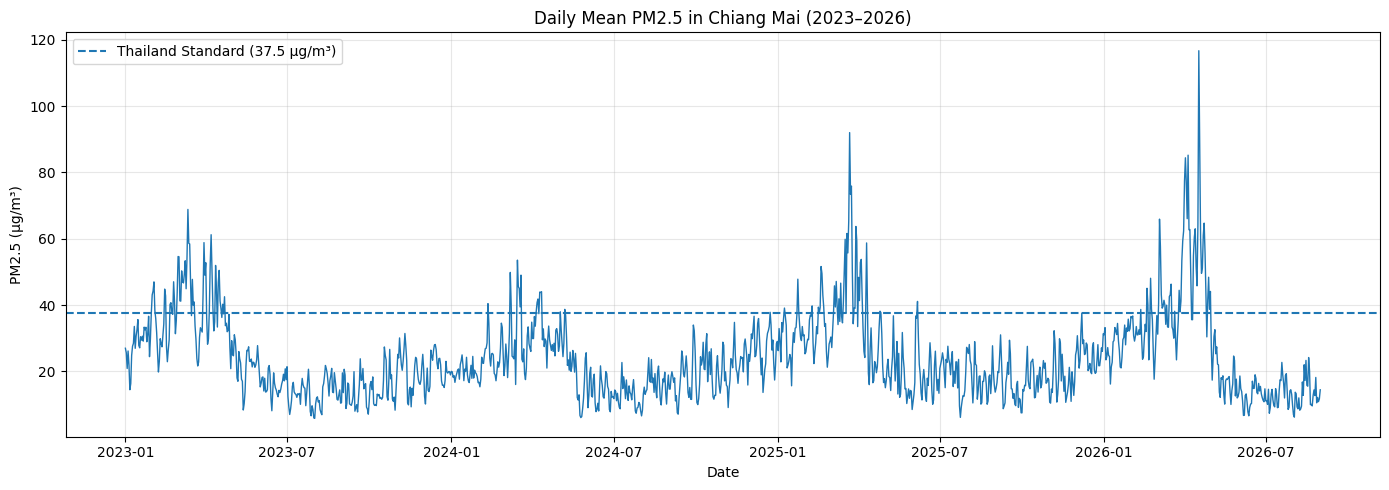

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    daily_df["date"],
    daily_df["pm2_5"],
    linewidth=1
)

# Thailand PM2.5 standard
plt.axhline(
    y=37.5,
    linestyle="--",
    label="Thailand Standard (37.5 µg/m³)"
)

plt.title("Daily Mean PM2.5 in Chiang Mai (2023–2026)")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "outputs/figures/fig01_pm25_timeseries.png",
    dpi=300
)

plt.show()

# Figure 2 — Dangerous Days by Month

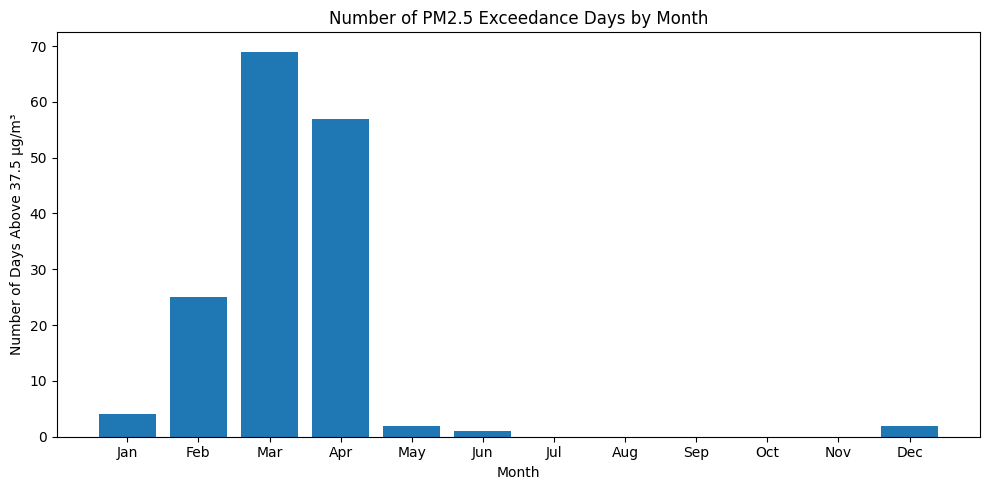

In [94]:
daily_df["month"] = daily_df["date"].dt.month

monthly_danger = (
    daily_df[daily_df["pm2_5"] > 37.5]
    .groupby("month")
    .size()
)

# Make sure all 12 months appear
monthly_danger = monthly_danger.reindex(
    range(1, 13),
    fill_value=0
)

month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(10, 5))

plt.bar(
    month_names,
    monthly_danger.values
)

plt.title("Number of PM2.5 Exceedance Days by Month")
plt.xlabel("Month")
plt.ylabel("Number of Days Above 37.5 µg/m³")

plt.tight_layout()

plt.savefig(
    "outputs/figures/fig02_danger_days_month.png",
    dpi=300
)

plt.show()

# Figure 3 — PM2.5 vs Wind Speed

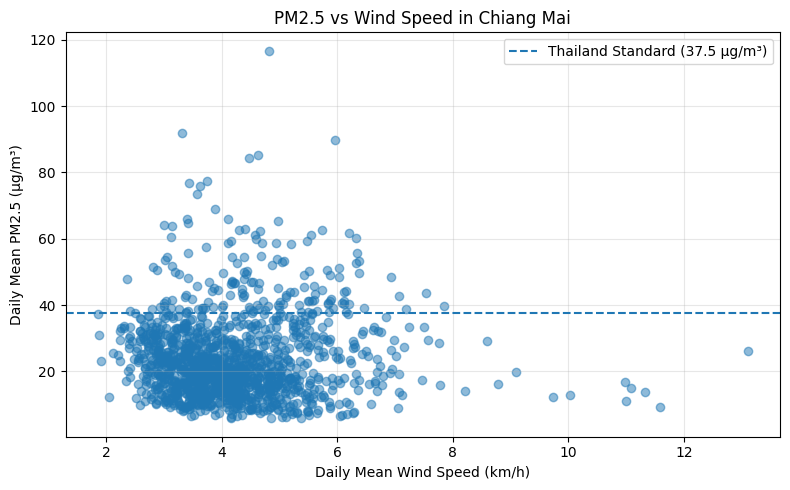

In [95]:
plt.figure(figsize=(8, 5))

plt.scatter(
    daily_df["wind_speed_10m"],
    daily_df["pm2_5"],
    alpha=0.5
)

plt.axhline(
    y=37.5,
    linestyle="--",
    label="Thailand Standard (37.5 µg/m³)"
)

plt.title("PM2.5 vs Wind Speed in Chiang Mai")
plt.xlabel("Daily Mean Wind Speed (km/h)")
plt.ylabel("Daily Mean PM2.5 (µg/m³)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "outputs/figures/fig03_pm25_wind.png",
    dpi=300
)

plt.show()

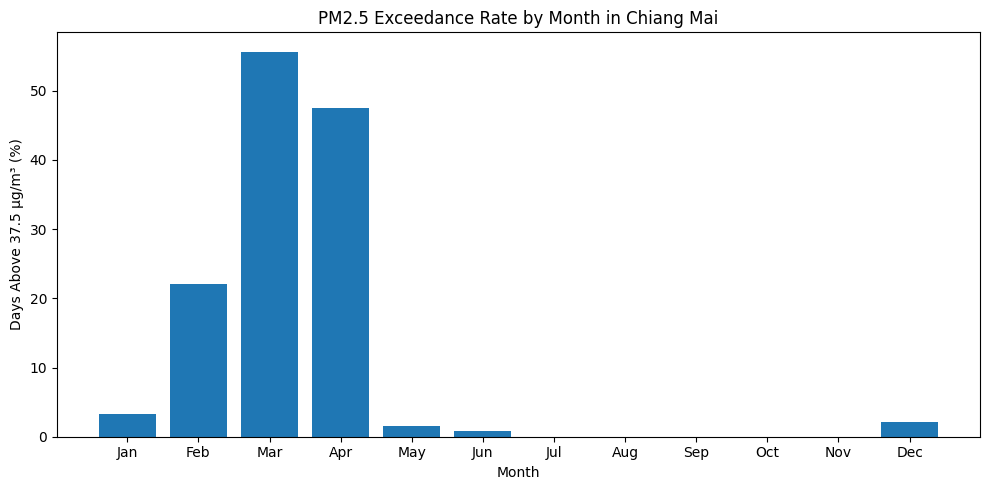

month
1      3.23
2     22.12
3     55.65
4     47.50
5      1.61
6      0.83
7      0.00
8      0.00
9      0.00
10     0.00
11     0.00
12     2.15
Name: exceed, dtype: float64


In [96]:
# Create exceedance indicator
daily_df["exceed"] = daily_df["pm2_5"] > 37.5

# Calculate percentage of days exceeding the standard for each month
monthly_rate = (
    daily_df
    .groupby("month")["exceed"]
    .mean() * 100
)

monthly_rate = monthly_rate.reindex(range(1, 13))

plt.figure(figsize=(10, 5))

plt.bar(
    month_names,
    monthly_rate.values
)

plt.title("PM2.5 Exceedance Rate by Month in Chiang Mai")
plt.xlabel("Month")
plt.ylabel("Days Above 37.5 µg/m³ (%)")

plt.tight_layout()

plt.savefig(
    "outputs/figures/fig02_pm25_exceedance_rate.png",
    dpi=300
)

plt.show()

print(monthly_rate.round(2))

In [97]:
wind_corr = daily_df["pm2_5"].corr(
    daily_df["wind_speed_10m"]
)

print(
    "Correlation between PM2.5 and wind speed:",
    round(wind_corr, 3)
)

Correlation between PM2.5 and wind speed: 0.025


In [98]:
weather_columns = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "precipitation",
    "surface_pressure"
]

correlations = (
    daily_df[weather_columns]
    .corrwith(daily_df["pm2_5"])
    .sort_values()
)

print("Correlation with PM2.5")
print("----------------------")
print(correlations.round(3))

Correlation with PM2.5
----------------------
relative_humidity_2m   -0.657
precipitation          -0.450
wind_speed_10m          0.025
temperature_2m          0.118
surface_pressure        0.217
dtype: float64


# New_Figure 3  — Humidity vs PM2.5

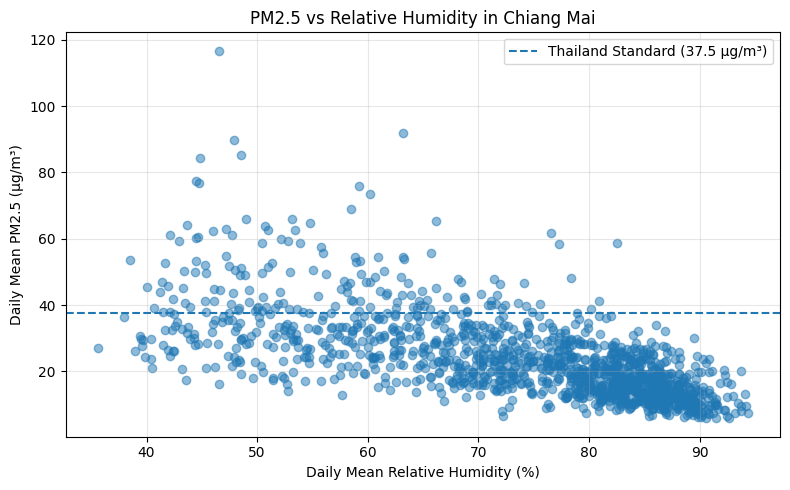

In [99]:
plt.figure(figsize=(8, 5))

plt.scatter(
    daily_df["relative_humidity_2m"],
    daily_df["pm2_5"],
    alpha=0.5
)

plt.axhline(
    y=37.5,
    linestyle="--",
    label="Thailand Standard (37.5 µg/m³)"
)

plt.title("PM2.5 vs Relative Humidity in Chiang Mai")
plt.xlabel("Daily Mean Relative Humidity (%)")
plt.ylabel("Daily Mean PM2.5 (µg/m³)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "outputs/figures/fig03_pm25_humidity.png",
    dpi=300
)

plt.show()

Daily PM2.5 showed a moderately strong negative association with relative humidity (r = -0.657). Higher PM2.5 concentrations tended to occur on days with lower relative humidity. However, this correlation does not establish a causal relationship.

In [100]:
# Create tomorrow's PM2.5
daily_df["pm25_tomorrow"] = daily_df["pm2_5"].shift(-1)

# Binary target:
# 1 = tomorrow exceeds Thailand standard
# 0 = tomorrow does not exceed standard
daily_df["danger_tomorrow"] = (
    daily_df["pm25_tomorrow"] > 37.5
).astype(int)

# The final row has no tomorrow value, so remove it
ml_df = daily_df.dropna(
    subset=["pm25_tomorrow"]
).copy()

print("ML dataset shape:", ml_df.shape)

ml_df[
    ["date", "pm2_5", "pm25_tomorrow", "danger_tomorrow"]
].head(10)

ML dataset shape: (1338, 15)


,date,pm2_5,pm25_tomorrow,danger_tomorrow
0,2023-01-01,26.991667,25.625000,0
1,2023-01-02,25.625000,20.904167,0
2,2023-01-03,20.904167,26.170833,0
3,2023-01-04,26.170833,21.966667,0
4,2023-01-05,21.966667,14.487500,0
5,2023-01-06,14.487500,16.337500,0
6,2023-01-07,16.337500,24.841667,0
7,2023-01-08,24.841667,27.616667,0
8,2023-01-09,27.616667,28.466667,0
9,2023-01-10,28.466667,33.570833,0


In [101]:
class_counts = ml_df["danger_tomorrow"].value_counts()
class_percent = (
    ml_df["danger_tomorrow"]
    .value_counts(normalize=True) * 100
)

print("Class Counts")
print(class_counts)

print("\nClass Percentage")
print(class_percent.round(2))

Class Counts
danger_tomorrow
0    1178
1     160
Name: count, dtype: int64

Class Percentage
danger_tomorrow
0    88.04
1    11.96
Name: proportion, dtype: float64


In [102]:
features = [
    "pm2_5",
    "pm10",
    "carbon_monoxide",
    "dust",
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "wind_direction_10m",
    "precipitation",
    "surface_pressure"
]

X = ml_df[features]
y = ml_df["danger_tomorrow"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1338, 10)
y shape: (1338,)


In [103]:
split_index = int(len(ml_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

date_train = ml_df["date"].iloc[:split_index]
date_test = ml_df["date"].iloc[split_index:]

print("Training")
print("Rows:", len(X_train))
print(
    "Date:",
    date_train.min(),
    "to",
    date_train.max()
)

print("\nTesting")
print("Rows:", len(X_test))
print(
    "Date:",
    date_test.min(),
    "to",
    date_test.max()
)

Training
Rows: 1070
Date: 2023-01-01 00:00:00 to 2025-12-05 00:00:00

Testing
Rows: 268
Date: 2025-12-06 00:00:00 to 2026-08-30 00:00:00


In [104]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Persistence baseline:
# Predict tomorrow using today's PM2.5 status
baseline_pred = (
    X_test["pm2_5"] > 37.5
).astype(int)

print("=== Persistence Baseline ===")
print("Accuracy :", round(accuracy_score(y_test, baseline_pred), 3))
print("Precision:", round(precision_score(y_test, baseline_pred, zero_division=0), 3))
print("Recall   :", round(recall_score(y_test, baseline_pred, zero_division=0), 3))
print("F1-score :", round(f1_score(y_test, baseline_pred, zero_division=0), 3))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, baseline_pred))

=== Persistence Baseline ===
Accuracy : 0.918
Precision: 0.788
Recall   : 0.788
F1-score : 0.788

Confusion Matrix
[[205  11]
 [ 11  41]]


In [105]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy :", round(accuracy_score(y_test, log_pred), 3))
print("Precision:", round(precision_score(y_test, log_pred, zero_division=0), 3))
print("Recall   :", round(recall_score(y_test, log_pred, zero_division=0), 3))
print("F1-score :", round(f1_score(y_test, log_pred, zero_division=0), 3))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, log_pred))

=== Logistic Regression ===
Accuracy : 0.843
Precision: 0.56
Recall   : 0.904
F1-score : 0.691

Confusion Matrix
[[179  37]
 [  5  47]]


In [106]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("=== Random Forest ===")
print("Accuracy :", round(accuracy_score(y_test, rf_pred), 3))
print("Precision:", round(precision_score(y_test, rf_pred, zero_division=0), 3))
print("Recall   :", round(recall_score(y_test, rf_pred, zero_division=0), 3))
print("F1-score :", round(f1_score(y_test, rf_pred, zero_division=0), 3))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

=== Random Forest ===
Accuracy : 0.899
Precision: 0.719
Recall   : 0.788
F1-score : 0.752

Confusion Matrix
[[200  16]
 [ 11  41]]


In [107]:
results = pd.DataFrame({
    "Model": [
        "Persistence Baseline",
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred)
    ],

    "Precision": [
        precision_score(y_test, baseline_pred, zero_division=0),
        precision_score(y_test, log_pred, zero_division=0),
        precision_score(y_test, rf_pred, zero_division=0)
    ],

    "Recall": [
        recall_score(y_test, baseline_pred, zero_division=0),
        recall_score(y_test, log_pred, zero_division=0),
        recall_score(y_test, rf_pred, zero_division=0)
    ],

    "F1": [
        f1_score(y_test, baseline_pred, zero_division=0),
        f1_score(y_test, log_pred, zero_division=0),
        f1_score(y_test, rf_pred, zero_division=0)
    ]
})

results.round(3)

,Model,Accuracy,Precision,Recall,F1
0,Persistence Baseline,0.918,0.788,0.788,0.788
1,Logistic Regression,0.843,0.560,0.904,0.691
2,Random Forest,0.899,0.719,0.788,0.752


In [108]:
error_df = ml_df.iloc[split_index:].copy()

error_df["actual"] = y_test.values
error_df["predicted"] = log_pred

false_negatives = error_df[
    (error_df["actual"] == 1) &
    (error_df["predicted"] == 0)
]

print("False Negative Days")
print("-------------------")

false_negatives[
    [
        "date",
        "pm2_5",
        "pm25_tomorrow",
        "relative_humidity_2m",
        "precipitation",
        "wind_speed_10m"
    ]
]

False Negative Days
-------------------


,date,pm2_5,pm25_tomorrow,relative_humidity_2m,precipitation,wind_speed_10m
1070,2025-12-06,32.033333,37.583333,79.666667,0.8,3.570833
1136,2026-02-10,31.187500,38.691667,71.833333,0.0,3.020833
1147,2026-02-21,32.591667,48.091667,77.875000,0.0,3.354167
1165,2026-03-11,34.204167,39.975000,78.750000,3.7,5.341667
1211,2026-04-26,30.420833,41.562500,73.916667,0.5,3.525000


# Figure 4 --- Confusion Matrix

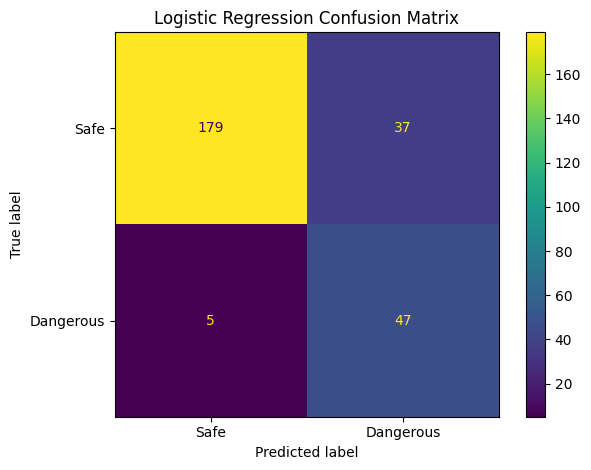

In [109]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    log_pred,
    display_labels=["Safe", "Dangerous"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "outputs/figures/fig04_confusion_matrix.png",
    dpi=300
)

plt.show()

The Logistic Regression model correctly identified 47 of the 52 dangerous days in the test period, achieving a recall of 0.904. It missed only 5 dangerous days, but produced 37 false-positive warnings. This demonstrates a trade-off between detecting most hazardous PM2.5 days and issuing additional false alarms.

In [110]:
features

['pm2_5',
 'pm10',
 'carbon_monoxide',
 'dust',
 'temperature_2m',
 'relative_humidity_2m',
 'wind_speed_10m',
 'wind_direction_10m',
 'precipitation',
 'surface_pressure']

In [111]:
# C5 - Leakage Audit

forbidden_features = [
    "pm25_tomorrow",
    "danger_tomorrow"
]

leakage_found = [
    col for col in forbidden_features
    if col in X.columns
]

print("Features used by the model:")
print(X.columns.tolist())

print("\nFuture information found:")
print(leakage_found)

if len(leakage_found) == 0:
    print("\nPASS: No future target information is used as a feature.")
else:
    print("\nWARNING: Data leakage detected!")

Features used by the model:
['pm2_5', 'pm10', 'carbon_monoxide', 'dust', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'wind_direction_10m', 'precipitation', 'surface_pressure']

Future information found:
[]

PASS: No future target information is used as a feature.


In [112]:
leakage_audit = pd.DataFrame({
    "Feature": features,
    "Available_at_prediction_time": ["Yes"] * len(features),
    "Uses_future_information": ["No"] * len(features)
})

leakage_audit

,Feature,Available_at_prediction_time,Uses_future_information
0,pm2_5,Yes,No
1,pm10,Yes,No
2,carbon_monoxide,Yes,No
3,dust,Yes,No
4,temperature_2m,Yes,No
5,relative_humidity_2m,Yes,No
6,wind_speed_10m,Yes,No
7,wind_direction_10m,Yes,No
8,precipitation,Yes,No
9,surface_pressure,Yes,No


In [113]:
error_df = ml_df.iloc[split_index:].copy()

error_df["actual"] = y_test.values
error_df["predicted"] = log_pred

false_negatives = error_df[
    (error_df["actual"] == 1) &
    (error_df["predicted"] == 0)
]

false_negatives[
    [
        "date",
        "pm2_5",
        "pm25_tomorrow",
        "relative_humidity_2m",
        "precipitation",
        "wind_speed_10m"
    ]
]

,date,pm2_5,pm25_tomorrow,relative_humidity_2m,precipitation,wind_speed_10m
1070,2025-12-06,32.033333,37.583333,79.666667,0.8,3.570833
1136,2026-02-10,31.187500,38.691667,71.833333,0.0,3.020833
1147,2026-02-21,32.591667,48.091667,77.875000,0.0,3.354167
1165,2026-03-11,34.204167,39.975000,78.750000,3.7,5.341667
1211,2026-04-26,30.420833,41.562500,73.916667,0.5,3.525000


In [114]:
false_negatives = false_negatives.copy()

false_negatives["pm25_change"] = (
    false_negatives["pm25_tomorrow"]
    - false_negatives["pm2_5"]
)

false_negatives[
    [
        "date",
        "pm2_5",
        "pm25_tomorrow",
        "pm25_change"
    ]
]

,date,pm2_5,pm25_tomorrow,pm25_change
1070,2025-12-06,32.033333,37.583333,5.550000
1136,2026-02-10,31.187500,38.691667,7.504167
1147,2026-02-21,32.591667,48.091667,15.500000
1165,2026-03-11,34.204167,39.975000,5.770833
1211,2026-04-26,30.420833,41.562500,11.141667


In [115]:
results.to_csv(
    "outputs/results/model_comparison.csv",
    index=False
)

false_negatives.to_csv(
    "outputs/results/false_negative_cases.csv",
    index=False
)

print("Results saved!")

Results saved!


# สรุป Checkpoints C1–C5

## Reproducibility Checkpoints

### C1 — Timezone and Time Axes
Both Open-Meteo endpoints were requested using the `Asia/Bangkok` timezone.
The Air Quality and Weather datasets were aligned using hourly timestamps before aggregation into Thailand local calendar days.

### C2 — Join Sanity
Air Quality and Weather data were joined using the `time` column with an inner join.
The number of rows before and after the join was checked to ensure that unexpected observations were not lost.

### C3 — Missing Data
Missing values were checked for every column before modeling.
The percentage of missing values was calculated using:

`missing percentage = missing count / total rows × 100`

### C4 — Time Split
The dataset was split chronologically rather than randomly.

- Training: 1 January 2023 – 5 December 2025 (1,070 observations)
- Testing: 6 December 2025 – 30 August 2026 (268 observations)

Therefore, all test observations occur after the training observations.

### C5 — Leakage Audit
The model uses only information available on day t to predict whether PM2.5 on day t+1 will exceed 37.5 µg/m³.

The future PM2.5 value (`pm25_tomorrow`) and target (`danger_tomorrow`) were not included as model features. Therefore, no future target information was used during prediction.

### C6 — Ground Truth Check
Pending comparison with an overlapping Air4Thai observation.

## Results Summary

The analysis found a clear seasonal pattern in Chiang Mai PM2.5 concentrations. PM2.5 levels were generally highest during February–April.

March had the highest PM2.5 exceedance rate, with 55.65% of observed days exceeding Thailand's 24-hour PM2.5 standard of 37.5 µg/m³. April followed with an exceedance rate of 47.50%.

Relative humidity showed the strongest linear association among the selected weather variables, with a correlation of -0.657 with PM2.5. Precipitation also showed a negative correlation of -0.450. These relationships represent associations and should not be interpreted as causal effects.

For next-day classification, the Persistence Baseline achieved an F1-score of 0.788. Logistic Regression achieved a lower F1-score of 0.691 but the highest recall of 0.904. Random Forest achieved an F1-score of 0.752 and recall of 0.788.

The Logistic Regression model detected 47 of the 52 dangerous days in the test period and missed 5. However, it also produced 37 false-positive warnings.

The five false-negative cases occurred when PM2.5 increased from the current day to the following day and crossed the 37.5 µg/m³ threshold, suggesting that sudden increases are challenging for the model.

## Actionable Recommendation

Based on the observed seasonal pattern, PM2.5 preparedness in Chiang Mai should be strengthened during February–April, particularly in March and April when exceedance rates were highest.

A next-day warning system could prioritize recall when the goal is to avoid missing dangerous PM2.5 days. In this study, Logistic Regression detected 90.4% of dangerous days in the test period, although this came at the cost of additional false alarms.

Such warnings could be used as an additional decision-support signal for schools, outdoor activities, and sensitive groups. However, the model should not replace official air-quality monitoring or public-health advisories.

The system could be improved by incorporating additional information such as fire hotspots, biomass-burning indicators, boundary-layer conditions, and forecasts rather than relying only on same-day PM2.5 and weather observations.

## Limitations

1. The Open-Meteo data represent gridded/model-based environmental data and may differ from measurements recorded by a specific ground monitoring station.

2. The analysis uses data from one Chiang Mai coordinate and therefore may not represent spatial differences across the entire province.

3. The dataset covers January 2023 to August 2026, and 2026 is not a complete calendar year.

4. Correlations between weather variables and PM2.5 represent associations and do not demonstrate causation.

5. The prediction models use same-day observations to predict the following day. Sudden PM2.5 increases remain difficult to predict.

6. The Logistic Regression model achieved high recall but generated additional false-positive warnings.

7. External factors such as wildfire hotspots, agricultural burning, traffic emissions, and transboundary pollution were not directly included in the model.

In [116]:
ml_df.to_csv(
    "data/processed/modeling_dataset.csv",
    index=False
)

print("Modeling dataset saved!")

Modeling dataset saved!


In [117]:
import os

for root, dirs, files in os.walk("."):
    dirs[:] = [d for d in dirs if not d.startswith(".")]

    for file in files:
        if file.endswith((".csv", ".json", ".png")):
            print(os.path.join(root, file))

./outputs/results/model_comparison.csv
./outputs/results/false_negative_cases.csv
./outputs/figures/fig02_danger_days_month.png
./outputs/figures/fig02_pm25_exceedance_rate.png
./outputs/figures/fig03_pm25_humidity.png
./outputs/figures/fig04_confusion_matrix.png
./outputs/figures/fig01_pm25_timeseries.png
./outputs/figures/fig03_pm25_wind.png
./data/raw/open_meteo_weather_archive.json
./data/raw/open_meteo_air_quality.json
./data/processed/modeling_dataset.csv
./data/processed/daily_merged.csv
./data/processed/hourly_merged.csv


In [118]:
import os

for root, dirs, files in os.walk("."):
    # Skip hidden/system folders
    dirs[:] = [
        d for d in dirs
        if not d.startswith(".")
    ]

    for file in files:
        if (
            file.endswith(".csv")
            or file.endswith(".json")
            or file.endswith(".png")
        ):
            print(os.path.join(root, file))

./outputs/results/model_comparison.csv
./outputs/results/false_negative_cases.csv
./outputs/figures/fig02_danger_days_month.png
./outputs/figures/fig02_pm25_exceedance_rate.png
./outputs/figures/fig03_pm25_humidity.png
./outputs/figures/fig04_confusion_matrix.png
./outputs/figures/fig01_pm25_timeseries.png
./outputs/figures/fig03_pm25_wind.png
./data/raw/open_meteo_weather_archive.json
./data/raw/open_meteo_air_quality.json
./data/processed/modeling_dataset.csv
./data/processed/daily_merged.csv
./data/processed/hourly_merged.csv


In [119]:
fetch_script = r'''
import os
import json
import requests
import pandas as pd

# --------------------------------
# Configuration
# --------------------------------

LATITUDE = 18.80
LONGITUDE = 99.00

START_DATE = "2023-01-01"
END_DATE = "2026-08-31"

AIR_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"
WEATHER_URL = "https://archive-api.open-meteo.com/v1/archive"

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)


# --------------------------------
# 1. Download Air Quality
# --------------------------------

air_params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "hourly": "pm2_5,pm10,carbon_monoxide,dust",
    "start_date": START_DATE,
    "end_date": END_DATE,
    "timezone": "Asia/Bangkok"
}

air_response = requests.get(
    AIR_URL,
    params=air_params,
    timeout=60
)

air_response.raise_for_status()
air_data = air_response.json()

with open(
    "data/raw/open_meteo_air_quality.json",
    "w"
) as f:
    json.dump(air_data, f, indent=4)

print("Air-quality data downloaded.")


# --------------------------------
# 2. Download Weather
# --------------------------------

weather_params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "hourly": (
        "temperature_2m,"
        "relative_humidity_2m,"
        "wind_speed_10m,"
        "wind_direction_10m,"
        "precipitation,"
        "surface_pressure"
    ),
    "start_date": START_DATE,
    "end_date": END_DATE,
    "timezone": "Asia/Bangkok"
}

weather_response = requests.get(
    WEATHER_URL,
    params=weather_params,
    timeout=60
)

weather_response.raise_for_status()
weather_data = weather_response.json()

with open(
    "data/raw/open_meteo_weather_archive.json",
    "w"
) as f:
    json.dump(weather_data, f, indent=4)

print("Weather data downloaded.")


# --------------------------------
# 3. Convert to DataFrames
# --------------------------------

air_df = pd.DataFrame(air_data["hourly"])
weather_df = pd.DataFrame(weather_data["hourly"])

air_df["time"] = pd.to_datetime(air_df["time"])
weather_df["time"] = pd.to_datetime(weather_df["time"])

print("Air rows:", len(air_df))
print("Weather rows:", len(weather_df))


# --------------------------------
# 4. Merge
# --------------------------------

hourly_df = pd.merge(
    air_df,
    weather_df,
    on="time",
    how="inner"
)

print("Rows after join:", len(hourly_df))

hourly_df.to_csv(
    "data/processed/hourly_merged.csv",
    index=False
)


# --------------------------------
# 5. Aggregate Hourly -> Daily
# --------------------------------

hourly_df["date"] = hourly_df["time"].dt.date

daily_df = hourly_df.groupby("date").agg({
    "pm2_5": "mean",
    "pm10": "mean",
    "carbon_monoxide": "mean",
    "dust": "mean",
    "temperature_2m": "mean",
    "relative_humidity_2m": "mean",
    "wind_speed_10m": "mean",
    "wind_direction_10m": "mean",
    "precipitation": "sum",
    "surface_pressure": "mean"
}).reset_index()

daily_df["date"] = pd.to_datetime(daily_df["date"])

daily_df.to_csv(
    "data/processed/daily_merged.csv",
    index=False
)

print("Daily rows:", len(daily_df))
print("Date range:", daily_df["date"].min(), "to", daily_df["date"].max())

print("\nData acquisition completed successfully.")
'''

with open("fetch_data.py", "w") as f:
    f.write(fetch_script)

print("fetch_data.py created!")

fetch_data.py created!


In [120]:
!python fetch_data.py

Air-quality data downloaded.
Weather data downloaded.
Air rows: 32136
Weather rows: 32136
Rows after join: 32136
Daily rows: 1339
Date range: 2023-01-01 00:00:00 to 2026-08-31 00:00:00

Data acquisition completed successfully.


In [121]:
requirements = """pandas
numpy
requests
matplotlib
scikit-learn
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created!")

requirements.txt created!


In [122]:
with open("requirements.txt", "r") as f:
    print(f.read())

pandas
numpy
requests
matplotlib
scikit-learn



In [123]:
readme = """# HW04 - Data Science vs PM2.5

## Project Overview

This project analyzes PM2.5 air pollution in Chiang Mai, Thailand using air-quality and weather data from Open-Meteo.

The project investigates seasonal PM2.5 patterns, relationships between PM2.5 and weather conditions, and whether dangerous PM2.5 conditions can be predicted one day in advance.

A day is classified as dangerous when the daily mean PM2.5 concentration exceeds Thailand's 24-hour standard of 37.5 µg/m³.

## Study Area

- Location: Chiang Mai, Thailand
- Latitude: 18.80
- Longitude: 99.00
- Timezone: Asia/Bangkok
- Study period: 2023-01-01 to 2026-08-31

## Data Sources

Data are obtained programmatically from Open-Meteo APIs.

1. Open-Meteo Air Quality API
   - PM2.5
   - PM10
   - Carbon monoxide
   - Dust

2. Open-Meteo Historical Weather API
   - Temperature
   - Relative humidity
   - Wind speed
   - Wind direction
   - Precipitation
   - Surface pressure

Raw API responses are saved in `data/raw/`.

## Project Structure

    .
    ├── fetch_data.py
    ├── analysis.ipynb
    ├── requirements.txt
    ├── README.md
    ├── data/
    │   ├── raw/
    │   │   ├── open_meteo_air_quality.json
    │   │   └── open_meteo_weather_archive.json
    │   └── processed/
    │       ├── hourly_merged.csv
    │       ├── daily_merged.csv
    │       └── modeling_dataset.csv
    └── outputs/
        ├── figures/
        └── results/

## How to Reproduce

### 1. Install dependencies

    pip install -r requirements.txt

### 2. Download and prepare the data

    python fetch_data.py

This downloads the Open-Meteo data and creates the hourly and daily processed datasets.

### 3. Run the analysis

Open and run:

    analysis.ipynb

Run all notebook cells from top to bottom.

## Analysis

The project includes:

- PM2.5 descriptive statistics
- PM2.5 time-series analysis
- Monthly exceedance-rate analysis
- Weather and PM2.5 correlation analysis
- Next-day dangerous PM2.5 prediction
- Persistence baseline
- Logistic Regression
- Random Forest
- Accuracy, Precision, Recall and F1-score
- Confusion matrix
- False-negative error analysis

## Main Findings

PM2.5 shows a strong seasonal pattern in Chiang Mai, with the highest exceedance rates occurring during February-April.

March had the highest exceedance rate in the study data.

Relative humidity showed the strongest negative correlation with PM2.5 among the selected weather variables.

For next-day classification, Logistic Regression achieved high recall for dangerous days, while the Persistence Baseline achieved the highest F1-score among the evaluated approaches.

False-negative analysis showed that missed dangerous days tended to occur when PM2.5 increased rapidly from one day to the next.

## Limitations

The Open-Meteo data are gridded/model-based environmental data and may differ from measurements at individual ground stations.

The analysis represents one coordinate in Chiang Mai and does not capture all spatial variation across the province.

External factors such as wildfire hotspots, agricultural burning, traffic emissions and transboundary pollution were not directly included in the prediction models.

## Ground Truth Check

One overlapping observation will be compared with Air4Thai PM2.5 data as an external ground-truth sanity check.

## Author

HW04 - Data Science vs PM2.5
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("README.md created!")

README.md created!


In [124]:
import os

required_files = [
    "fetch_data.py",
    "requirements.txt",
    "README.md"
]

for file in required_files:
    if os.path.exists(file):
        print("OK:", file)
    else:
        print("MISSING:", file)

OK: fetch_data.py
OK: requirements.txt
OK: README.md


In [125]:
import shutil

shutil.make_archive(
    "/kaggle/working/HW04_PM25_files",
    "zip",
    "/kaggle/working",
    "data"
)

print("ZIP created!")

ZIP created!


## C6 - Ground Truth Validation with Air4Thai

To validate the Open-Meteo PM2.5 data, I compared it with ground-station data from Air4Thai at Yupparaj Wittayalai School, Chiang Mai, on 31 August 2026.

In [126]:
# C6 - Ground Truth Validation

open_meteo_pm25 = 11.2667
air4thai_pm25 = 8.80

absolute_difference = abs(open_meteo_pm25 - air4thai_pm25)

print(f"Open-Meteo PM2.5 : {open_meteo_pm25:.2f} µg/m³")
print(f"Air4Thai PM2.5    : {air4thai_pm25:.2f} µg/m³")
print(f"Absolute difference: {absolute_difference:.2f} µg/m³")

Open-Meteo PM2.5 : 11.27 µg/m³
Air4Thai PM2.5    : 8.80 µg/m³
Absolute difference: 2.47 µg/m³


### Interpretation

On 31 August 2026, the Open-Meteo daily mean PM2.5 was approximately **11.27 µg/m³**, while the Air4Thai PM2.5 value at Yupparaj Wittayalai School was approximately **8.80 µg/m³**.

The absolute difference was approximately **2.47 µg/m³**.

The two values are reasonably close but are not expected to be identical. Air4Thai represents measurements from a specific ground monitoring station, whereas Open-Meteo provides gridded/model-based air-quality data.

This comparison provides a ground-truth check of the Open-Meteo data used in this study. The Air4Thai value was estimated from the hourly values displayed in the Air4Thai historical-data graph, so the comparison should be interpreted as an approximate validation rather than an exact sensor-to-grid match.